Meta-training Prototypical Network on Seen Classes...
Episode 020/120 | Meta-Loss: 0.0000
Episode 040/120 | Meta-Loss: 0.0001
Episode 060/120 | Meta-Loss: 0.0000
Episode 080/120 | Meta-Loss: 0.0000
Episode 100/120 | Meta-Loss: 0.0000
Episode 120/120 | Meta-Loss: 0.0000

FEW-SHOT METRICS ON DISJOINT CLASSES
3-Way 5-Shot Accuracy on Unseen Shapes: 80.40%


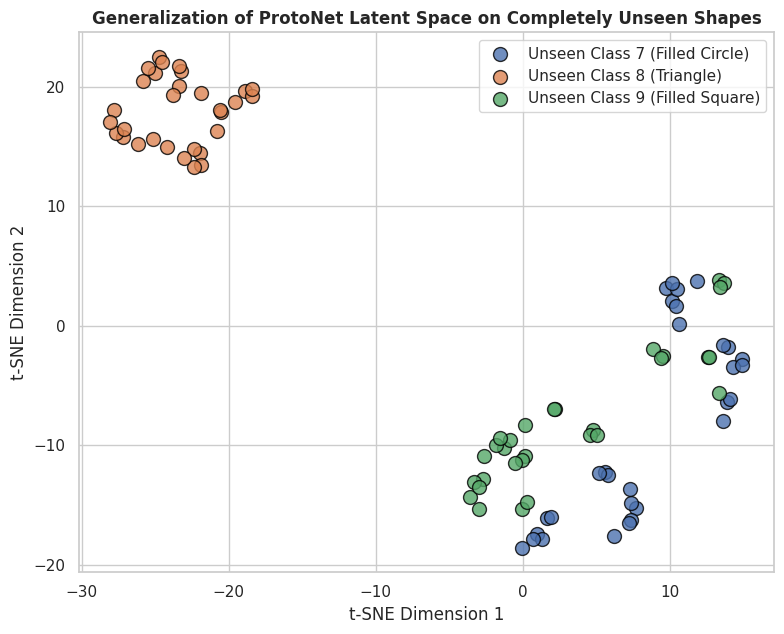

In [ ]:

# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import numpy as np  # fast math
import torch  # deep learning
import torch.nn as nn  # neural layers
import torch.nn.functional as F  # math functions
import torch.optim as optim  # model trainers
from PIL import Image, ImageDraw  # draw images
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling
from sklearn.manifold import TSNE  # visual clustering

warnings.filterwarnings('ignore')  # hide warnings

SEED = 42  # standard seed
torch.manual_seed(SEED)  # seed pytorch
np.random.seed(SEED)  # seed numpy

# ==========================================
# 1. Custom Geometric Dataset Generator
# ==========================================

def generate_geometric_images():
    classes_data = []  # data list
    for c in range(10):  # loop 10 distinct shapes
        class_images = []  # class collection
        for i in range(30):  # 30 samples per shape
            img = Image.new('L', (28, 28), color=0)  # base black canvas
            draw = ImageDraw.Draw(img)  # canvas drawing tool

            # Add spatial jitter noise
            offset_x = np.random.randint(-2, 3)  # x shift
            offset_y = np.random.randint(-2, 3)  # y shift

            if c == 0:  # vertical line
                draw.line([(14+offset_x, 4+offset_y), (14+offset_x, 24+offset_y)], fill=255, width=2)
            elif c == 1:  # horizontal line
                draw.line([(4+offset_x, 14+offset_y), (24+offset_x, 14+offset_y)], fill=255, width=2)
            elif c == 2:  # center circle
                draw.ellipse([(8+offset_x, 8+offset_y), (20+offset_x, 20+offset_y)], outline=255, width=2)
            elif c == 3:  # square outline
                draw.rectangle([(8+offset_x, 8+offset_y), (20+offset_x, 20+offset_y)], outline=255, width=2)
            elif c == 4:  # cross
                draw.line([(14+offset_x, 6+offset_y), (14+offset_x, 22+offset_y)], fill=255, width=2)
                draw.line([(6+offset_x, 14+offset_y), (22+offset_x, 14+offset_y)], fill=255, width=2)
            elif c == 5:  # diagonal line 1
                draw.line([(6+offset_x, 6+offset_y), (22+offset_x, 22+offset_y)], fill=255, width=2)
            elif c == 6:  # diagonal line 2
                draw.line([(22+offset_x, 6+offset_y), (6+offset_x, 22+offset_y)], fill=255, width=2)
            elif c == 7:  # filled circle
                draw.ellipse([(11+offset_x, 11+offset_y), (17+offset_x, 17+offset_y)], fill=255)
            elif c == 8:  # triangle
                draw.polygon([(14+offset_x, 6+offset_y), (6+offset_x, 22+offset_y), (22+offset_x, 22+offset_y)], outline=255, width=2)
            elif c == 9:  # filled square
                draw.rectangle([(11+offset_x, 11+offset_y), (17+offset_x, 17+offset_y)], fill=255)

            arr = np.array(img, dtype=np.float32)  # cast array
            arr += np.random.normal(0, 15, arr.shape)  # add subtle noise
            arr = np.clip(arr, 0, 255) / 255.0  # normalize pixels
            class_images.append(arr)  # save sample
        classes_data.append(class_images)  # save class
    return np.array(classes_data)  # return array

# ==========================================
# 2. Prototypical Network Architecture
# ==========================================

# ConvBlock: Sequential block with Conv2d → BatchNorm → ReLU → MaxPool - extracts spatial features while reducing dimensions by half.
class ConvBlock(nn.Module):  # sequential block
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),  # conv
            nn.BatchNorm2d(out_channels),  # batch normalization
            nn.ReLU(),  # activation
            nn.MaxPool2d(2)  # spatial pooling
        )
    def forward(self, x):
        return self.net(x)  # return forward pass

# ProtoNet: Encoder with 4 ConvBlocks (1→32→32→32→32), flattening to 32-dim embeddings - maps images to prototype space for few-shot learning.
class ProtoNet(nn.Module):  # prototypical mapping encoder
    def __init__(self, in_channels=1, hidden_dim=32, z_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(in_channels, hidden_dim),  # block 1
            ConvBlock(hidden_dim, hidden_dim),  # block 2
            ConvBlock(hidden_dim, hidden_dim),  # block 3
            ConvBlock(hidden_dim, z_dim)  # block 4
        )
    def forward(self, x):
        x = self.encoder(x)  # run blocks
        return x.view(x.size(0), -1)  # flatten outputs

# EuclideanDist: Computes pairwise squared distances between queries and prototypes - expands dimensions then sums squared differences along feature axis.
def euclidean_dist(x, y):  # pairwise metric calculation
    n = x.size(0)  # query count
    m = y.size(0)  # prototype count
    d = x.size(1)  # latent dimensions
    x = x.unsqueeze(1).expand(n, m, d)  # expand query dimensions
    y = y.unsqueeze(0).expand(n, m, d)  # expand prototype dimensions
    return torch.pow(x - y, 2).sum(2)  # sum squared differences

# ==========================================
# 3. Episodic Few-Shot Sampling
# ==========================================

def sample_episode(data, classes, n_way, k_shot, q_query):
    chosen_classes = np.random.choice(classes, n_way, replace=False)  # select classes
    support_set, query_set = [], []  # empty containers

    for c in chosen_classes:  # loop selected categories
        indices = np.random.choice(data.shape[1], k_shot + q_query, replace=False)  # random samples
        support_set.append(data[c, indices[:k_shot]])  # save support subset
        query_set.append(data[c, indices[k_shot:]])  # save query subset

    support_set = torch.FloatTensor(np.array(support_set)).unsqueeze(2)  # shape (n_way, k_shot, 1, 28, 28)
    query_set = torch.FloatTensor(np.array(query_set)).unsqueeze(2)  # shape (n_way, q_query, 1, 28, 28)
    return support_set, query_set, chosen_classes  # return episode variables

# ==========================================
# 4. Training Loop (Meta-Learning)
# ==========================================

# Split 10 geometric shape categories into Seen (training) and Unseen (testing) classes
data = generate_geometric_images()  # build custom shapes
train_classes = list(range(7))  # classes 0-6: SEEN training set
test_classes = list(range(7, 10))  # classes 7-9: UNSEEN test set (disjoint!)

model = ProtoNet(in_channels=1, hidden_dim=32, z_dim=32)  # init model instance
optimizer = optim.Adam(model.parameters(), lr=0.005)  # optimizer setup

print("Meta-training Prototypical Network on Seen Classes...")  # log status
model.train()  # set training
for episode in range(120):  # episodic epochs
    support, query, _ = sample_episode(data, train_classes, n_way=3, k_shot=5, q_query=5)  # sample 3-way 5-shot episode

    n_way, k_shot, c, h, w = support.shape  # support dims
    q_query = query.shape[1]  # query dims

    support_flat = support.view(n_way * k_shot, c, h, w)  # support flat batch
    query_flat = query.view(n_way * q_query, c, h, w)  # query flat batch

    support_embeddings = model(support_flat)  # calculate support embeddings
    query_embeddings = model(query_flat)  # calculate query embeddings

    prototypes = support_embeddings.view(n_way, k_shot, -1).mean(dim=1)  # compute average class prototypes
    dists = euclidean_dist(query_embeddings, prototypes)  # compute distances matrix
    y_query = torch.arange(n_way).repeat_interleave(q_query)  # generate labels mapping

    loss = F.cross_entropy(-dists, y_query)  # negative distance cross-entropy

    optimizer.zero_grad()  # clear gradient variables
    loss.backward()  # backpropagation
    optimizer.step()  # update weights

    if (episode + 1) % 20 == 0:  # interval logging
        print(f"Episode {episode+1:03d}/120 | Meta-Loss: {loss.item():.4f}")

# ==========================================
# 5. Meta-Testing Evaluation (Disjoint Unseen Classes)
# ==========================================

model.eval()  # freeze batchnorm and dropouts
test_accs = []  # save accuracy scores

with torch.no_grad():  # freeze gradients
    for _ in range(50):  # test over 50 random test episodes
        support, query, _ = sample_episode(data, test_classes, n_way=3, k_shot=5, q_query=5)  # sample unseen episode
        n_way, k_shot, c, h, w = support.shape  # support dims
        q_query = query.shape[1]  # query dims

        support_flat = support.view(n_way * k_shot, c, h, w)  # support flat batch
        query_flat = query.view(n_way * q_query, c, h, w)  # query flat batch

        support_embeddings = model(support_flat)  # support embeddings
        query_embeddings = model(query_flat)  # query embeddings

        prototypes = support_embeddings.view(n_way, k_shot, -1).mean(dim=1)  # average prototypes
        dists = euclidean_dist(query_embeddings, prototypes)  # query-to-prototype distances
        y_query = torch.arange(n_way).repeat_interleave(q_query)  # label mapping

        preds = torch.argmax(-dists, dim=1)  # predictions (minimum distance)
        acc = (preds == y_query).float().mean().item()  # accuracy fraction
        test_accs.append(acc)  # save score

print("\n=====================================")
print("FEW-SHOT METRICS ON DISJOINT CLASSES")
print("=====================================")
print(f"3-Way 5-Shot Accuracy on Unseen Shapes: {np.mean(test_accs)*100:.2f}%")
print("=====================================")

# ==========================================
# 6. Visualizing Latent Space Separation
# ==========================================

# Collect all samples of unseen classes to draw projection clusters
model.eval()  # freeze weights
all_test_imgs = torch.FloatTensor(data[7:]).unsqueeze(2)  # float tensor shape: (3, 30, 1, 28, 28)
n_cl, n_sa, ch, hh, ww = all_test_imgs.shape  # test shapes

with torch.no_grad():  # freeze gradients
    embeddings = model(all_test_imgs.view(n_cl * n_sa, ch, hh, ww)).cpu().numpy()  # extract test embeddings

# Compress multi-dimensional embeddings to 2D using t-SNE
tsne = TSNE(n_components=2, perplexity=10, random_state=SEED)  # tsne instance
reduced = tsne.fit_transform(embeddings)  # map embeddings to 2D
labels = np.arange(3).repeat(n_sa)  # class indices mapping (0=Filled Circle, 1=Triangle, 2=Filled Square)

sns.set_theme(style="whitegrid")  # set style
plt.figure(figsize=(8, 6.5))  # canvas layout
shape_labels = {0: 'Unseen Class 7 (Filled Circle)', 1: 'Unseen Class 8 (Triangle)', 2: 'Unseen Class 9 (Filled Square)'}  # readable labels

for i in range(3):  # loop test classes
    idx = labels == i  # select category indexes
    plt.scatter(reduced[idx, 0], reduced[idx, 1], alpha=0.8, edgecolors='black', s=100, label=shape_labels[i])  # draw scatter cluster

plt.xlabel('t-SNE Dimension 1')  # x axis
plt.ylabel('t-SNE Dimension 2')  # y axis
plt.title('Generalization of ProtoNet Latent Space on Completely Unseen Shapes', fontsize=12, fontweight='bold')  # plot title
plt.legend()  # compile legend
plt.tight_layout()  # fit components
plt.show()  # render plot